X shape: (200, 2)  | classi: [-1  1]


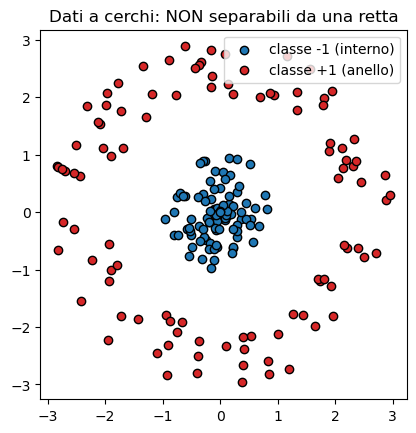

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC          # il "motore" SMO

np.random.seed(0)
mp = 100                              # punti per classe

# CLASSE -1: blob INTERNO (raggio piccolo 0..1)
r0 = np.random.rand(mp); t0 = np.random.rand(mp)*2*np.pi
X0 = np.c_[r0*np.cos(t0), r0*np.sin(t0)]

# CLASSE +1: ANELLO esterno (raggio 2..3)
r1 = 2 + np.random.rand(mp); t1 = np.random.rand(mp)*2*np.pi
X1 = np.c_[r1*np.cos(t1), r1*np.sin(t1)]

X = np.vstack([X0, X1])               # (200, 2)
y = np.array([-1]*mp + [1]*mp)        # etichette -1 / +1  (la notazione SVM!)
m = X.shape[0]

print('X shape:', X.shape, ' | classi:', np.unique(y))

plt.scatter(X[y==-1,0], X[y==-1,1], color='#1f77b4', edgecolors='k', label='classe -1 (interno)')
plt.scatter(X[y==1,0],  X[y==1,1],  color='#d62728', edgecolors='k', label='classe +1 (anello)')
plt.gca().set_aspect('equal'); plt.legend()
plt.title('Dati a cerchi: NON separabili da una retta'); plt.show()

accuracy LINEARE: 70.5 %


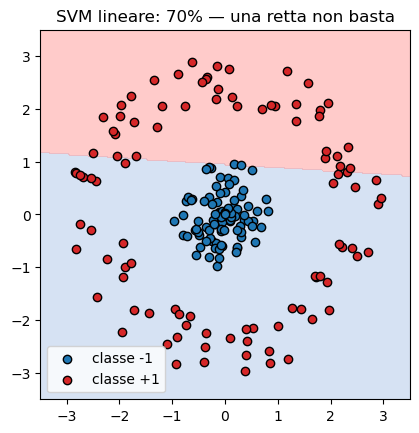

In [2]:
# SVM LINEARE: prova a separare con una RETTA (è l'optimal margin classifier della lez. 6)
lin = SVC(kernel='linear', C=1.0)
lin.fit(X, y)                          # .fit() = qui gira SMO sotto il cofano
print('accuracy LINEARE:', round(lin.score(X, y)*100, 1), '%')

# disegno il confine lineare che ha trovato
xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, 300), np.linspace(-3.5, 3.5, 300))
griglia = np.c_[xx.ravel(), yy.ravel()]
Z = lin.predict(griglia).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=[-1.5, 0, 1.5], colors=['#aec7e8', '#ff9896'], alpha=0.5)
plt.scatter(X[y==-1,0], X[y==-1,1], color='#1f77b4', edgecolors='k', label='classe -1')
plt.scatter(X[y==1,0],  X[y==1,1],  color='#d62728', edgecolors='k', label='classe +1')
plt.gca().set_aspect('equal'); plt.legend()
plt.title(f'SVM lineare: {lin.score(X,y)*100:.0f}% — una retta non basta'); plt.show()

accuracy RBF   : 100.0 %
support vectors: 18 su 200


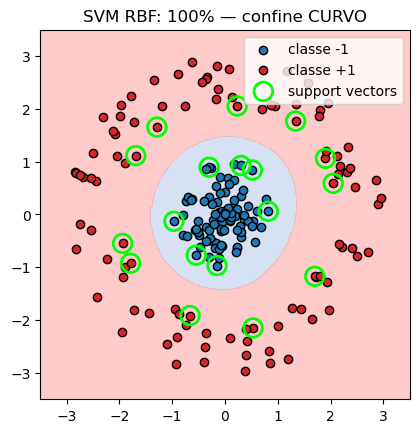

In [3]:
# SVM con KERNEL GAUSSIANO (RBF):  K(x,z) = exp(-gamma * ||x-z||^2)
gamma = 0.5
rbf = SVC(kernel='rbf', C=1.0, gamma=gamma)
rbf.fit(X, y)
print('accuracy RBF   :', round(rbf.score(X, y)*100, 1), '%')
print('support vectors:', rbf.support_vectors_.shape[0], 'su', m)

# confine di decisione (ora CURVO)
xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, 300), np.linspace(-3.5, 3.5, 300))
griglia = np.c_[xx.ravel(), yy.ravel()]
Z = rbf.predict(griglia).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=[-1.5, 0, 1.5], colors=['#aec7e8', '#ff9896'], alpha=0.5)
plt.scatter(X[y==-1,0], X[y==-1,1], color='#1f77b4', edgecolors='k', label='classe -1')
plt.scatter(X[y==1,0],  X[y==1,1],  color='#d62728', edgecolors='k', label='classe +1')

# evidenzio i SUPPORT VECTOR (i punti con alpha > 0)
SV = rbf.support_vectors_
plt.scatter(SV[:,0], SV[:,1], s=180, facecolors='none', edgecolors='lime',
          linewidths=2, label='support vectors')
plt.gca().set_aspect('equal'); plt.legend()
plt.title(f'SVM RBF: {rbf.score(X,y)*100:.0f}% — confine CURVO'); plt.show()

In [4]:
# Estraggo dal modello RBF i tre ingredienti della predizione
SV   = rbf.support_vectors_       # i support vector (i punti con alpha > 0)
coef = rbf.dual_coef_[0]          # = alpha_i * y_i  per ogni support vector (sklearn li dà già moltiplicati)
b    = rbf.intercept_[0]          # l'intercetta
print('numero di support vector:', SV.shape[0])

# Il kernel gaussiano, scritto A MANO:  K(a,b) = exp(-gamma * ||a-b||^2)
def Krbf(A, B):
  d = A[:, None, :] - B[None, :, :]        # tutte le differenze (a - b) tra righe di A e di B
  return np.exp(-gamma * np.sum(d**2, axis=2))

# La predizione DELLA TEORIA:  f(x) = Σ_i (alpha_i y_i) K(sv_i, x) + b
def f_mano(Xq):
  return Krbf(Xq, SV) @ coef + b

# VERIFICA: i miei numeri coincidono con quelli di sklearn?
mio = f_mano(X)
skl = rbf.decision_function(X)
print('max differenza |mio - sklearn|:', np.max(np.abs(mio - skl)))
print('le predizioni (segno) coincidono?', np.array_equal(np.sign(mio), np.sign(skl)))

numero di support vector: 18
max differenza |mio - sklearn|: 1.7763568394002505e-15
le predizioni (segno) coincidono? True


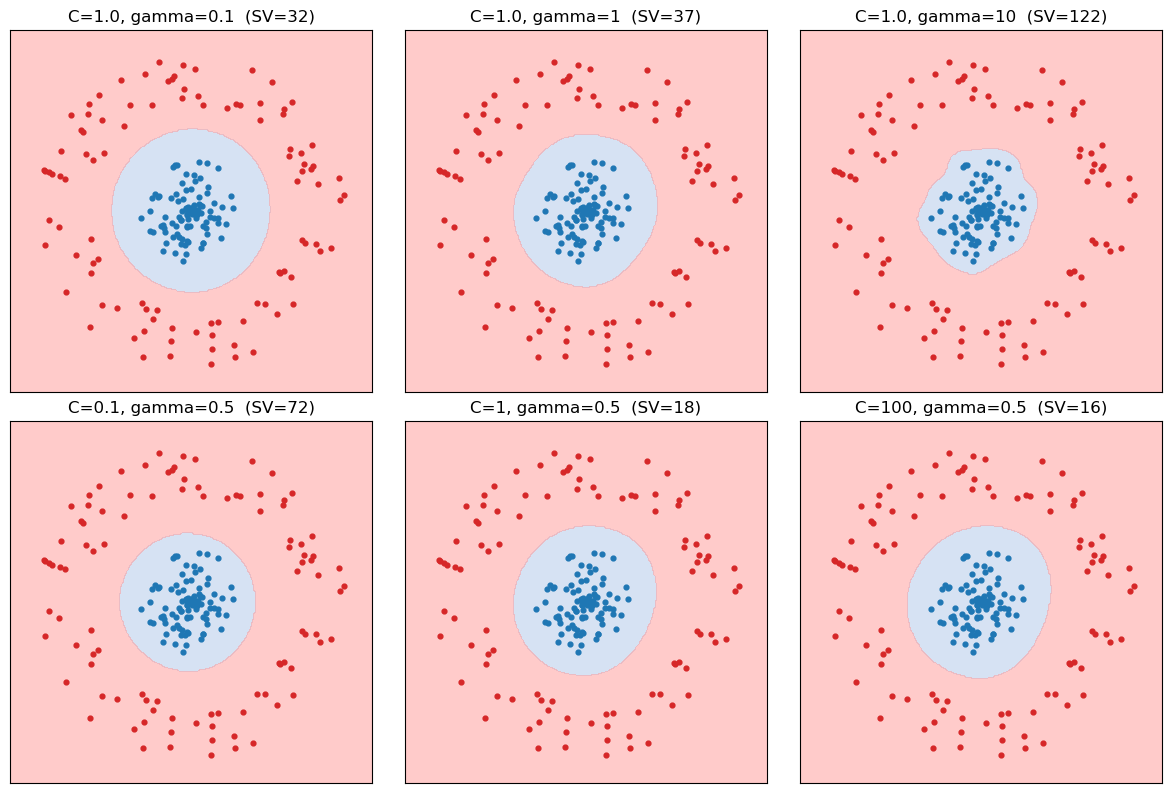

In [5]:
# Disegna il confine di una SVM (C, gamma) su un asse
xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, 300), np.linspace(-3.5, 3.5, 300))
griglia = np.c_[xx.ravel(), yy.ravel()]

def disegna(ax, C, gamma):
  s = SVC(kernel='rbf', C=C, gamma=gamma).fit(X, y)
  Z = s.predict(griglia).reshape(xx.shape)
  ax.contourf(xx, yy, Z, levels=[-1.5,0,1.5], colors=['#aec7e8','#ff9896'], alpha=0.5)
  ax.scatter(X[y==-1,0], X[y==-1,1], color='#1f77b4', s=12)
  ax.scatter(X[y==1,0],  X[y==1,1],  color='#d62728', s=12)
  ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
  ax.set_title(f'C={C}, gamma={gamma}  (SV={s.support_vectors_.shape[0]})')

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# RIGA 1: vario GAMMA (C fisso = 1)
for ax, g in zip(axes[0], [0.1, 1, 10]):
  disegna(ax, C=1.0, gamma=g)

# RIGA 2: vario C (gamma fisso = 0.5)
for ax, c in zip(axes[1], [0.1, 1, 100]):
  disegna(ax, C=c, gamma=0.5)

plt.tight_layout(); plt.show()